# AAI-540 Group Project
## Machine Learning-Based RF Intrusion Detection System

### Group 6

This project develops a supervised multi-class machine learning system for classifying radiofrequency (RF) activity using spectrogram images.

The objective is to identify different RF activity categories and provide a repeatable machine learning workflow that supports data preparation, model training, evaluation, deployment, and monitoring.


## 1. Environment Setup

This section imports the libraries required for data inspection, visualization, preprocessing, and machine learning. Random seeds are also defined to support reproducibility across notebook runs.


In [1]:
# ============================================
# Environment Setup
# ============================================

import os
import random
from collections import Counter

import numpy as np
import matplotlib.pyplot as plt
from PIL import Image

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

from sklearn.metrics import (
    classification_report,
    confusion_matrix
)

import warnings
warnings.filterwarnings("ignore")

# Reproducibility
SEED = 42

random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

print("TensorFlow version:", tf.__version__)
print("Environment setup complete.")


2026-09-25 22:46:23.017055: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX512F, in other operations, rebuild TensorFlow with the appropriate compiler flags.


TensorFlow version: 2.19.1
Environment setup complete.


## 2. Dataset Location and Access

The Unified Multi-Class RF Intrusion Dataset is stored in Amazon S3 and copied into the SageMaker environment for analysis and model development.

The dataset is organized into predefined training, validation, and test directories, which are used throughout the project.


In [2]:
# ============================================
# Load Dataset from SageMaker Local Storage
# ============================================

dataset_dir = "/home/sagemaker-user/aai-540-final-project-group6/data/unified_dataset"

train_dir = os.path.join(dataset_dir, "train")
val_dir = os.path.join(dataset_dir, "val")
test_dir = os.path.join(dataset_dir, "test")

print("Dataset directory:", dataset_dir)
print("Training directory:", train_dir)
print("Validation directory:", val_dir)
print("Testing directory:", test_dir)

print("\nDataset contents:")
print(os.listdir(dataset_dir))


Dataset directory: /home/sagemaker-user/aai-540-final-project-group6/data/unified_dataset
Training directory: /home/sagemaker-user/aai-540-final-project-group6/data/unified_dataset/train
Validation directory: /home/sagemaker-user/aai-540-final-project-group6/data/unified_dataset/val
Testing directory: /home/sagemaker-user/aai-540-final-project-group6/data/unified_dataset/test

Dataset contents:
['test', 'dataset_verification.png', 'train', 'val']


## 3. Dataset Structure

This section verifies the dataset directory structure and confirms that the expected training, validation, and test partitions are available before further processing.


In [3]:
# ============================================
# Inspect Dataset Structure
# ============================================

print("Top-level dataset contents:\n")

for item in sorted(os.listdir(dataset_dir)):
    item_path = os.path.join(dataset_dir, item)

    if os.path.isdir(item_path):
        print(f"[DIR]  {item}")
    else:
        print(f"[FILE] {item}")


Top-level dataset contents:

[FILE] dataset_verification.png
[DIR]  test
[DIR]  train
[DIR]  val


In [4]:
# ============================================
# Define Dataset Splits
# ============================================

train_dir = os.path.join(dataset_dir, "train")
val_dir = os.path.join(dataset_dir, "val")
test_dir = os.path.join(dataset_dir, "test")

print("Training directory:", train_dir)
print("Validation directory:", val_dir)
print("Testing directory:", test_dir)


Training directory: /home/sagemaker-user/aai-540-final-project-group6/data/unified_dataset/train
Validation directory: /home/sagemaker-user/aai-540-final-project-group6/data/unified_dataset/val
Testing directory: /home/sagemaker-user/aai-540-final-project-group6/data/unified_dataset/test


## 4. RF Activity Classes

The dataset contains six RF activity classes:

- Benign
- Broadband Jam
- Human
- Machine
- Narrowband Jam
- Wildlife

These folder names serve as the class labels for the supervised multi-class classification problem.


In [5]:
# ============================================
# Identify RF Classes
# ============================================

class_names = sorted([
    folder
    for folder in os.listdir(train_dir)
    if os.path.isdir(os.path.join(train_dir, folder))
])

print(f"Number of classes: {len(class_names)}\n")

for i, class_name in enumerate(class_names):
    print(f"{i}: {class_name}")


Number of classes: 6

0: Benign
1: Broadband_Jam
2: Human
3: Machine
4: Narrowband_Jam
5: Wildlife


## 5. Dataset Distribution

The number of images in each class and dataset split is examined to identify potential class imbalance and confirm the total data volume available for training, validation, and testing.


In [6]:
# ============================================
# Count Images by Split and Class
# ============================================

def count_images(directory):
    counts = {}

    for class_name in class_names:
        class_dir = os.path.join(directory, class_name)

        counts[class_name] = len([
            file
            for file in os.listdir(class_dir)
            if file.lower().endswith(".png")
        ])

    return counts


train_counts = count_images(train_dir)
val_counts = count_images(val_dir)
test_counts = count_images(test_dir)

print("Class Distribution\n")

print(f"{'Class':<20} {'Train':>8} {'Val':>8} {'Test':>8} {'Total':>8}")
print("-" * 58)

for class_name in class_names:
    train_count = train_counts[class_name]
    val_count = val_counts[class_name]
    test_count = test_counts[class_name]
    total = train_count + val_count + test_count

    print(
        f"{class_name:<20}"
        f"{train_count:>8}"
        f"{val_count:>8}"
        f"{test_count:>8}"
        f"{total:>8}"
    )


Class Distribution

Class                   Train      Val     Test    Total
----------------------------------------------------------
Benign                  2800     600     600    4000
Broadband_Jam           2800     600     600    4000
Human                   2800     600     600    4000
Machine                 2800     600     600    4000
Narrowband_Jam          2800     600     600    4000
Wildlife                2800     600     600    4000


In [7]:
# ============================================
# Dataset Summary
# ============================================

total_train = sum(train_counts.values())
total_val = sum(val_counts.values())
total_test = sum(test_counts.values())

total_images = total_train + total_val + total_test

print("Dataset Summary")
print("-----------------")
print(f"Training images:   {total_train:,}")
print(f"Validation images: {total_val:,}")
print(f"Testing images:    {total_test:,}")
print(f"Total images:      {total_images:,}")


Dataset Summary
-----------------
Training images:   16,800
Validation images: 3,600
Testing images:    3,600
Total images:      24,000


## 6. Class Balance Analysis

Class distribution is visualized to determine whether any RF activity category is overrepresented or underrepresented.

A balanced dataset reduces the likelihood that the model will favor one class simply because it appears more frequently during training.


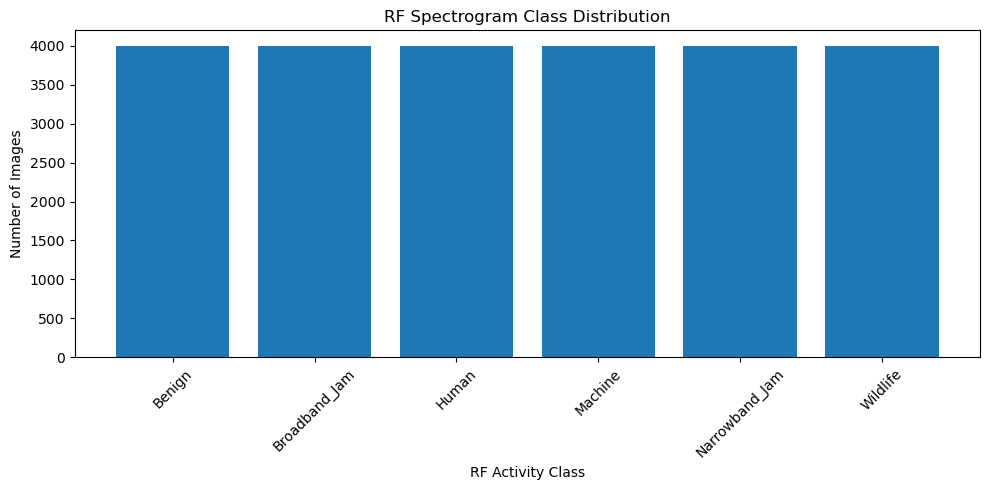

In [8]:
# ============================================
# Visualize Class Distribution
# ============================================

totals_by_class = [
    train_counts[c] + val_counts[c] + test_counts[c]
    for c in class_names
]

plt.figure(figsize=(10, 5))
plt.bar(class_names, totals_by_class)

plt.title("RF Spectrogram Class Distribution")
plt.xlabel("RF Activity Class")
plt.ylabel("Number of Images")

plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


## 7. RF Spectrogram Visualization

Sample spectrograms from each RF activity class are displayed to provide a visual understanding of the input data.

These images represent time-frequency characteristics of RF activity that the classification model will learn to distinguish.


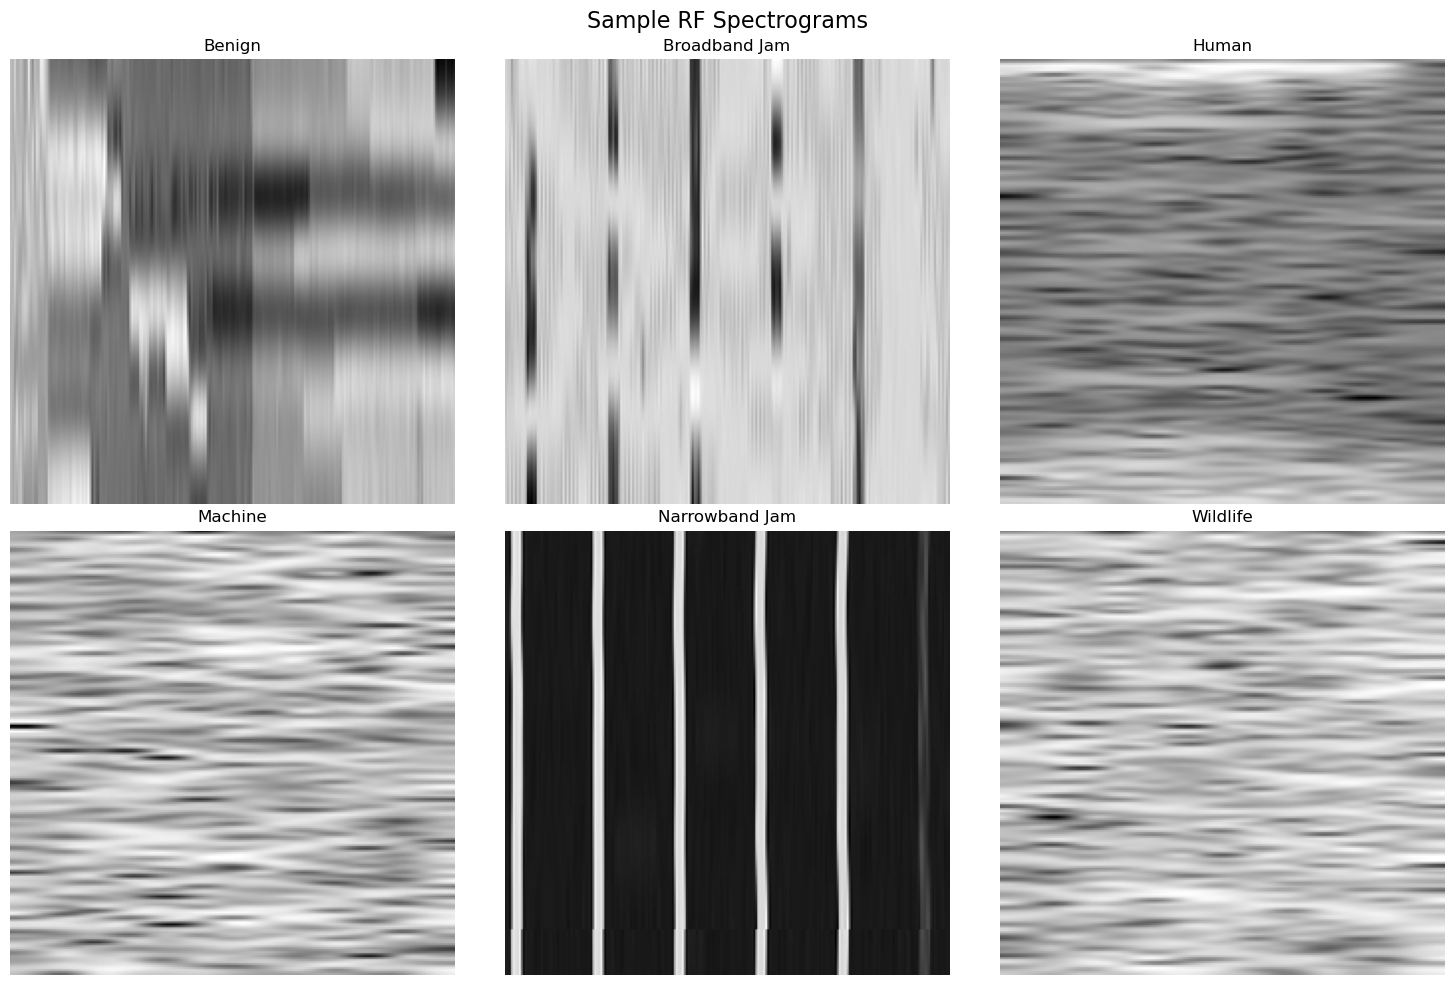

In [9]:
# ============================================
# Display One Spectrogram from Each Class
# ============================================

plt.figure(figsize=(15, 10))

for i, class_name in enumerate(class_names):

    class_dir = os.path.join(train_dir, class_name)

    image_files = [
        file
        for file in os.listdir(class_dir)
        if file.lower().endswith(".png")
    ]

    sample_file = random.choice(image_files)
    image_path = os.path.join(class_dir, sample_file)

    with Image.open(image_path) as image:
        plt.subplot(2, 3, i + 1)
        plt.imshow(image, cmap="gray")
        plt.title(class_name.replace("_", " "))
        plt.axis("off")

plt.suptitle("Sample RF Spectrograms", fontsize=16)
plt.tight_layout()
plt.show()


## 8. Image Properties and Data Quality

The image dimensions and color modes are inspected to verify the consistency of the RF spectrogram data before model development.


In [10]:
# ============================================
# Inspect Spectrogram Image Properties
# ============================================

sample_class = class_names[0]

sample_files = [
    file for file in os.listdir(os.path.join(train_dir, sample_class))
    if file.lower().endswith(".png")
]

sample_path = os.path.join(
    train_dir,
    sample_class,
    sample_files[0]
)

with Image.open(sample_path) as sample_image:
    print("Class:", sample_class)
    print("Image size:", sample_image.size)
    print("Image mode:", sample_image.mode)
    print("Image format:", sample_image.format)


Class: Benign
Image size: (224, 224)
Image mode: L
Image format: PNG


## 9. Image Consistency Check

A sample of training images is reviewed across all six RF classes to confirm that image dimensions and formats are consistent across the dataset.


In [11]:
# ============================================
# Check Image Dimensions Across All Classes
# ============================================

image_sizes = Counter()
image_modes = Counter()

samples_per_class = 100
sampled = 0

for class_name in class_names:

    class_dir = os.path.join(train_dir, class_name)

    image_files = [
        file for file in os.listdir(class_dir)
        if file.lower().endswith(".png")
    ]

    sample_files = image_files[:samples_per_class]

    for file in sample_files:

        image_path = os.path.join(class_dir, file)

        with Image.open(image_path) as img:
            image_sizes[img.size] += 1
            image_modes[img.mode] += 1

        sampled += 1

print("Sampled images:", sampled)

print("\nImage dimensions:")
for size, count in image_sizes.items():
    print(size, ":", count)

print("\nImage modes:")
for mode, count in image_modes.items():
    print(mode, ":", count)


Sampled images: 600

Image dimensions:
(224, 224) : 600

Image modes:
L : 600


## 10. TensorFlow Data Pipeline

The predefined training, validation, and test directories are converted into TensorFlow datasets.

The original spectrogram files remain unchanged at 224 × 224 pixels. For CPU-efficient baseline training in the AWS Academy SageMaker environment, TensorFlow resizes the model inputs to 128 × 128 pixels, loads them as RGB tensors, and processes them in batches of 32.


In [12]:
# ============================================
# Create TensorFlow Image Datasets
# ============================================

IMG_HEIGHT = 128
IMG_WIDTH = 128
BATCH_SIZE = 32

train_ds = tf.keras.utils.image_dataset_from_directory(
    train_dir,
    image_size=(IMG_HEIGHT, IMG_WIDTH),
    batch_size=BATCH_SIZE,
    label_mode="categorical",
    color_mode="rgb",
    shuffle=True,
    seed=SEED
)

val_ds = tf.keras.utils.image_dataset_from_directory(
    val_dir,
    image_size=(IMG_HEIGHT, IMG_WIDTH),
    batch_size=BATCH_SIZE,
    label_mode="categorical",
    color_mode="rgb",
    shuffle=False
)

test_ds = tf.keras.utils.image_dataset_from_directory(
    test_dir,
    image_size=(IMG_HEIGHT, IMG_WIDTH),
    batch_size=BATCH_SIZE,
    label_mode="categorical",
    color_mode="rgb",
    shuffle=False
)

print("\nClasses:")
print(train_ds.class_names)


Found 16800 files belonging to 6 classes.
Found 3600 files belonging to 6 classes.
Found 3600 files belonging to 6 classes.

Classes:
['Benign', 'Broadband_Jam', 'Human', 'Machine', 'Narrowband_Jam', 'Wildlife']


## 11. Input Pipeline Optimization

TensorFlow prefetching is used to improve data-loading efficiency by preparing future batches while the model processes the current batch.

This helps reduce input bottlenecks during training.


In [13]:
# ============================================
# Optimize Input Pipeline
# ============================================

AUTOTUNE = tf.data.AUTOTUNE

train_ds = train_ds.prefetch(buffer_size=AUTOTUNE)
val_ds = val_ds.prefetch(buffer_size=AUTOTUNE)
test_ds = test_ds.prefetch(buffer_size=AUTOTUNE)

print("TensorFlow datasets ready.")


TensorFlow datasets ready.


## 12. Data Preparation Summary

The RF spectrogram dataset has been prepared for model development. The training, validation, and test splits are verified, all six RF activity classes are identified, class balance is evaluated, and image dimensions and formats are checked.

The TensorFlow input pipeline resizes model inputs to 128 × 128 pixels for CPU-efficient baseline training, loads the images as RGB tensors, applies categorical labels for multi-class classification, and uses prefetching to improve data-loading efficiency.

The dataset is now ready for baseline convolutional neural network (CNN) development.


## 13. Baseline CNN Model

A baseline convolutional neural network (CNN) is developed to classify the six RF spectrogram categories.

The baseline model provides an initial performance benchmark that can later be compared against more advanced architectures or transfer-learning approaches.


In [14]:
# ============================================
# Build Baseline CNN Model
# ============================================

num_classes = len(class_names)

model = tf.keras.Sequential([
    tf.keras.layers.Input(
        shape=(IMG_HEIGHT, IMG_WIDTH, 3)
    ),

    tf.keras.layers.Rescaling(1./255),

    tf.keras.layers.Conv2D(
        32,
        kernel_size=3,
        activation="relu",
        padding="same"
    ),
    tf.keras.layers.MaxPooling2D(),

    tf.keras.layers.Conv2D(
        64,
        kernel_size=3,
        activation="relu",
        padding="same"
    ),
    tf.keras.layers.MaxPooling2D(),

    tf.keras.layers.Conv2D(
        128,
        kernel_size=3,
        activation="relu",
        padding="same"
    ),
    tf.keras.layers.MaxPooling2D(),

    tf.keras.layers.GlobalAveragePooling2D(),

    tf.keras.layers.Dense(
        128,
        activation="relu"
    ),

    tf.keras.layers.Dropout(0.3),

    tf.keras.layers.Dense(
        num_classes,
        activation="softmax"
    )
])

model.summary()


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ rescaling (Rescaling)           │ (None, 128, 128, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 128, 128, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 64, 64, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 64, 64, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 32, 32, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 32, 32, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 16, 16, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 128)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │        16,512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 6)              │           774 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 110,534 (431.77 KB)

 Trainable params: 110,534 (431.77 KB)

 Non-trainable params: 0 (0.00 B)

## 14. Model Compilation

The baseline CNN is compiled using the Adam optimizer and categorical cross-entropy loss, which is appropriate for this six-class classification problem. Accuracy is tracked during training as an initial performance metric.


In [17]:
# ============================================
# Compile Baseline CNN Model
# ============================================

model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
    loss="categorical_crossentropy",
    metrics=["accuracy"]
)

print("Baseline CNN compiled successfully.")


Baseline CNN compiled successfully.


## 15. Baseline CNN Training

The baseline CNN is trained using the prepared training dataset and evaluated against the validation dataset after each epoch.

Early stopping is used to reduce unnecessary training if validation loss stops improving, while the best-performing model weights are restored automatically.


In [25]:
# ============================================
# Baseline CNN Training
# ============================================

early_stopping = tf.keras.callbacks.EarlyStopping(
    monitor="val_loss",
    patience=3,
    restore_best_weights=True
)

history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=15,
    callbacks=[early_stopping]
)

Epoch 1/15
525/525 ━━━━━━━━━━━━━━━━━━━━ 254s 480ms/step - accuracy: 0.5752 - loss: 0.9370 - val_accuracy: 0.6986 - val_loss: 0.6491
Epoch 2/15
525/525 ━━━━━━━━━━━━━━━━━━━━ 243s 462ms/step - accuracy: 0.6906 - loss: 0.6527 - val_accuracy: 0.7261 - val_loss: 0.5751
Epoch 3/15
525/525 ━━━━━━━━━━━━━━━━━━━━ 270s 478ms/step - accuracy: 0.7100 - loss: 0.6011 - val_accuracy: 0.7025 - val_loss: 0.6494
Epoch 4/15
525/525 ━━━━━━━━━━━━━━━━━━━━ 257s 468ms/step - accuracy: 0.7198 - loss: 0.5669 - val_accuracy: 0.7294 - val_loss: 0.5441
Epoch 5/15
525/525 ━━━━━━━━━━━━━━━━━━━━ 254s 453ms/step - accuracy: 0.7282 - loss: 0.5600 - val_accuracy: 0.7075 - val_loss: 0.5441
Epoch 6/15
525/525 ━━━━━━━━━━━━━━━━━━━━ 243s 464ms/step - accuracy: 0.7387 - loss: 0.5366 - val_accuracy: 0.7364 - val_loss: 0.5475
Epoch 7/15
525/525 ━━━━━━━━━━━━━━━━━━━━ 245s 468ms/step - accuracy: 0.7455 - loss: 0.5207 - val_accuracy: 0.7469 - val_loss: 0.5436
Epoch 8/15
525/525 ━━━━━━━━━━━━━━━━━━━━ 264s 472ms/step - accuracy: 0.7562 -

## 16. Test Set Evaluation

The trained baseline CNN is evaluated on the held-out test dataset to measure how well it generalizes to previously unseen RF spectrograms.

The test loss and test accuracy provide an overall performance benchmark that will later be compared against the improved CNN model.

In [26]:
# ============================================
# Test Set Evaluation
# ============================================

test_loss, test_accuracy = model.evaluate(
    test_ds,
    verbose=1
)

print("\nBaseline CNN Test Results")
print("-------------------------")
print(f"Test Loss:     {test_loss:.4f}")
print(f"Test Accuracy: {test_accuracy:.4f}")

113/113 ━━━━━━━━━━━━━━━━━━━━ 13s 118ms/step - accuracy: 0.8122 - loss: 0.4076

Baseline CNN Test Results
-------------------------
Test Loss:     0.4076
Test Accuracy: 0.8122


## 17. Classification Performance and Confusion Matrix

Overall test accuracy provides a useful summary of model performance, but it does not show how well the CNN performs on each individual RF activity class.

This section evaluates the baseline CNN using class-level precision, recall, and F1-score. A confusion matrix is also generated to identify which RF activity classes are most frequently confused by the model. These results will serve as a detailed reference when evaluating the improved CNN.

  1/113 ━━━━━━━━━━━━━━━━━━━━ 20s 185ms/step

2026-09-26 00:04:28.625175: I tensorflow/core/framework/local_rendezvous.cc:407] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence


113/113 ━━━━━━━━━━━━━━━━━━━━ 13s 116ms/step
Baseline CNN Classification Report
----------------------------------
                precision    recall  f1-score   support

        Benign     0.6865    0.8650    0.7655       600
 Broadband_Jam     0.9164    0.9867    0.9502       600
         Human     0.8754    0.8783    0.8769       600
       Machine     0.6416    0.4417    0.5232       600
Narrowband_Jam     0.9900    0.9933    0.9917       600
      Wildlife     0.7315    0.7083    0.7197       600

      accuracy                         0.8122      3600
     macro avg     0.8069    0.8122    0.8045      3600
  weighted avg     0.8069    0.8122    0.8045      3600



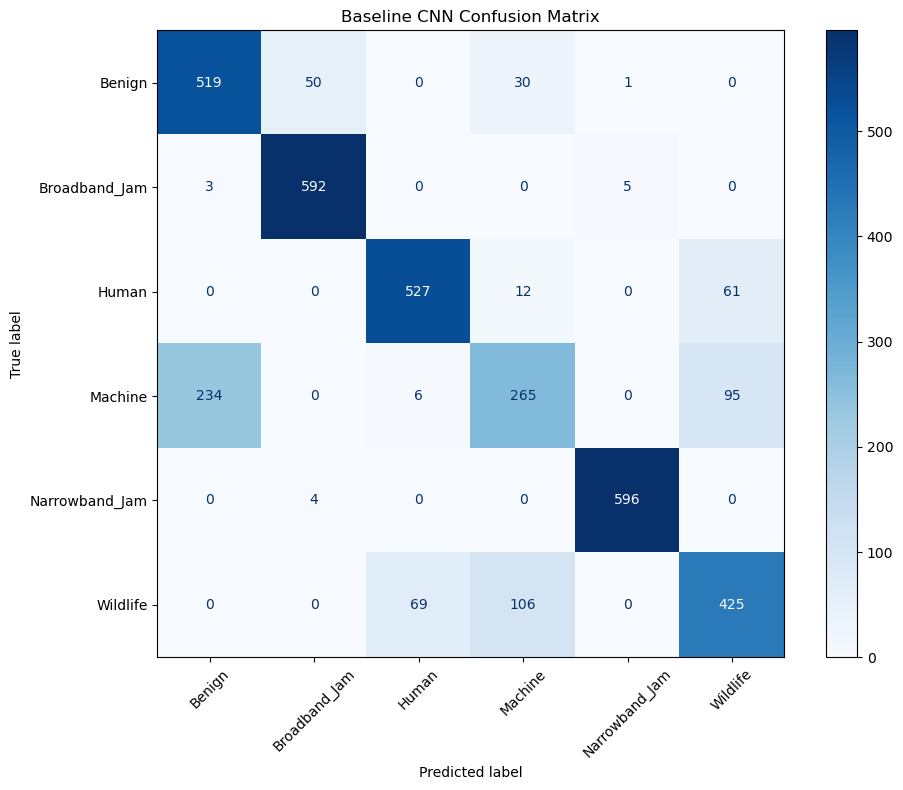

In [27]:
# ============================================
# Classification Performance
# ============================================

import numpy as np
import matplotlib.pyplot as plt

from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay
)

# Collect true labels from the test dataset
y_true = np.concatenate([
    np.argmax(labels.numpy(), axis=1)
    for images, labels in test_ds
])

# Generate class probabilities
y_prob = model.predict(
    test_ds,
    verbose=1
)

# Convert probabilities to predicted class labels
y_pred = np.argmax(
    y_prob,
    axis=1
)

# Classification report
print("Baseline CNN Classification Report")
print("----------------------------------")

print(
    classification_report(
        y_true,
        y_pred,
        target_names=class_names,
        digits=4
    )
)

# Confusion matrix
cm = confusion_matrix(
    y_true,
    y_pred
)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=class_names
)

fig, ax = plt.subplots(figsize=(10, 8))
disp.plot(
    ax=ax,
    cmap="Blues",
    values_format="d"
)

plt.title("Baseline CNN Confusion Matrix")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

## 18. Baseline Model Results

The baseline CNN achieved 81.22% accuracy on the held-out test dataset with a macro F1-score of approximately 0.8045.

Performance was strongest for the Broadband_Jam and Narrowband_Jam classes. The primary weakness was the Machine class, which achieved only 44.17% recall and an F1-score of approximately 0.5232. The confusion matrix shows that Machine samples were most frequently misclassified as Benign or Wildlife.

These baseline results establish the reference performance for the next model iteration. The improved CNN will focus on increasing overall classification performance while reducing confusion among the Benign, Machine, and Wildlife classes.

In [28]:
# ============================================
# Store Baseline CNN Results
# ============================================

from sklearn.metrics import precision_recall_fscore_support

baseline_precision, baseline_recall, baseline_macro_f1, _ = (
    precision_recall_fscore_support(
        y_true,
        y_pred,
        average="macro",
        zero_division=0
    )
)

baseline_results = {
    "model": "Baseline CNN v1",
    "test_loss": float(test_loss),
    "test_accuracy": float(test_accuracy),
    "macro_precision": float(baseline_precision),
    "macro_recall": float(baseline_recall),
    "macro_f1": float(baseline_macro_f1)
}

print("Baseline CNN v1 Results")
print("-----------------------")

for metric, value in baseline_results.items():
    if metric == "model":
        print(f"{metric}: {value}")
    else:
        print(f"{metric}: {value:.4f}")

Baseline CNN v1 Results
-----------------------
model: Baseline CNN v1
test_loss: 0.4076
test_accuracy: 0.8122
macro_precision: 0.8069
macro_recall: 0.8122
macro_f1: 0.8045


## 19. Preserve Baseline CNN for Comparison

The trained baseline CNN is retained as Model v1 before developing the improved architecture.

Keeping the baseline and improved models separate allows both versions to be evaluated using the same test dataset and performance metrics. This provides a consistent comparison of accuracy, precision, recall, F1-score, and class-level performance.

In [29]:
# ============================================
# Preserve Baseline CNN v1
# ============================================

baseline_model = model

print("Baseline CNN v1 preserved for comparison.")
print(f"Baseline Test Accuracy: {baseline_results['test_accuracy']:.4f}")
print(f"Baseline Macro F1:      {baseline_results['macro_f1']:.4f}")

Baseline CNN v1 preserved for comparison.
Baseline Test Accuracy: 0.8122
Baseline Macro F1:      0.8045


## 20. Improved CNN v2 Architecture

The second CNN iteration builds on the baseline model by increasing feature-extraction capacity while maintaining a relatively lightweight architecture.

The improved model adds batch normalization after each convolutional layer to stabilize training and introduces a fourth convolutional block to capture more complex patterns in the RF spectrograms. Dropout is also increased to provide additional regularization.

The goal of this iteration is to improve overall classification performance, with particular attention to the Machine class, which showed the weakest recall and F1-score in the baseline CNN.

In [30]:
# ============================================
# Improved CNN v2 Architecture
# ============================================

improved_model = tf.keras.Sequential([
    
    tf.keras.layers.Input(
        shape=(IMG_HEIGHT, IMG_WIDTH, 3)
    ),

    tf.keras.layers.Rescaling(1./255),

    # Convolution Block 1
    tf.keras.layers.Conv2D(
        32,
        kernel_size=3,
        padding="same",
        use_bias=False
    ),
    tf.keras.layers.BatchNormalization(),
    tf.keras.layers.ReLU(),
    tf.keras.layers.MaxPooling2D(),

    # Convolution Block 2
    tf.keras.layers.Conv2D(
        64,
        kernel_size=3,
        padding="same",
        use_bias=False
    ),
    tf.keras.layers.BatchNormalization(),
    tf.keras.layers.ReLU(),
    tf.keras.layers.MaxPooling2D(),

    # Convolution Block 3
    tf.keras.layers.Conv2D(
        128,
        kernel_size=3,
        padding="same",
        use_bias=False
    ),
    tf.keras.layers.BatchNormalization(),
    tf.keras.layers.ReLU(),
    tf.keras.layers.MaxPooling2D(),

    # Convolution Block 4
    tf.keras.layers.Conv2D(
        256,
        kernel_size=3,
        padding="same",
        use_bias=False
    ),
    tf.keras.layers.BatchNormalization(),
    tf.keras.layers.ReLU(),
    tf.keras.layers.MaxPooling2D(),

    # Classification Head
    tf.keras.layers.GlobalAveragePooling2D(),

    tf.keras.layers.Dense(
        128,
        activation="relu"
    ),

    tf.keras.layers.Dropout(0.40),

    tf.keras.layers.Dense(
        num_classes,
        activation="softmax"
    )
])

improved_model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ rescaling_1 (Rescaling)         │ (None, 128, 128, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 128, 128, 32)   │           864 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 128, 128, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ re_lu (ReLU)                    │ (None, 128, 128, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 64, 64, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 64, 64, 64)     │        18,432 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 64, 64, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ re_lu_1 (ReLU)                  │ (None, 64, 64, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 32, 32, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 32, 32, 128)    │        73,728 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 32, 32, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ re_lu_2 (ReLU)                  │ (None, 32, 32, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_5 (MaxPooling2D)  │ (None, 16, 16, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_6 (Conv2D)               │ (None, 16, 16, 256)    │       294,912 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 16, 16, 256)    │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ re_lu_3 (ReLU)                  │ (None, 16, 16, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_6 (MaxPooling2D)  │ (None, 8, 8, 256)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_1      │ (None, 256)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 6)              │           774 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 423,526 (1.62 MB)

 Trainable params: 422,566 (1.61 MB)

 Non-trainable params: 960 (3.75 KB)

## 21. Improved CNN v2 Compilation

The improved CNN is compiled using the Adam optimizer and categorical cross-entropy loss, consistent with the six-class classification objective.

A slightly lower learning rate than the baseline model is used to support more stable optimization of the deeper network. Accuracy is retained as the primary training metric, while precision, recall, and F1-score will be calculated during final evaluation.

In [31]:
# ============================================
# Improved CNN v2 Compilation
# ============================================

improved_model.compile(
    optimizer=tf.keras.optimizers.Adam(
        learning_rate=0.0005
    ),
    loss="categorical_crossentropy",
    metrics=["accuracy"]
)

print("Improved CNN v2 compiled successfully.")
print("Optimizer: Adam")
print("Learning Rate: 0.0005")
print("Loss: categorical_crossentropy")
print("Metric: accuracy")

Improved CNN v2 compiled successfully.
Optimizer: Adam
Learning Rate: 0.0005
Loss: categorical_crossentropy
Metric: accuracy


## 22. Improved CNN v2 Training

The improved CNN is trained using the same training and validation datasets as the baseline model to maintain a fair comparison.

Early stopping is used to restore the model weights associated with the lowest validation loss if performance stops improving. A learning-rate reduction callback is also included to decrease the learning rate when validation loss plateaus, allowing the optimizer to make smaller adjustments as training progresses.

The improved model is trained for a maximum of 20 epochs, although training may stop earlier if validation performance no longer improves.

In [32]:
# ============================================
# Improved CNN v2 Training
# ============================================

improved_early_stopping = tf.keras.callbacks.EarlyStopping(
    monitor="val_loss",
    patience=4,
    restore_best_weights=True,
    verbose=1
)

reduce_lr = tf.keras.callbacks.ReduceLROnPlateau(
    monitor="val_loss",
    factor=0.5,
    patience=2,
    min_lr=1e-6,
    verbose=1
)

history_v2 = improved_model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=20,
    callbacks=[
        improved_early_stopping,
        reduce_lr
    ]
)

Epoch 1/20
525/525 ━━━━━━━━━━━━━━━━━━━━ 463s 878ms/step - accuracy: 0.6783 - loss: 0.6863 - val_accuracy: 0.6417 - val_loss: 0.7760 - learning_rate: 5.0000e-04
Epoch 2/20
525/525 ━━━━━━━━━━━━━━━━━━━━ 464s 884ms/step - accuracy: 0.7351 - loss: 0.5496 - val_accuracy: 0.6961 - val_loss: 0.5709 - learning_rate: 5.0000e-04
Epoch 3/20
525/525 ━━━━━━━━━━━━━━━━━━━━ 468s 892ms/step - accuracy: 0.7579 - loss: 0.4982 - val_accuracy: 0.7253 - val_loss: 0.5383 - learning_rate: 5.0000e-04
Epoch 4/20
525/525 ━━━━━━━━━━━━━━━━━━━━ 465s 887ms/step - accuracy: 0.7771 - loss: 0.4495 - val_accuracy: 0.5914 - val_loss: 0.9588 - learning_rate: 5.0000e-04
Epoch 5/20
525/525 ━━━━━━━━━━━━━━━━━━━━ 0s 857ms/step - accuracy: 0.7906 - loss: 0.4212
Epoch 5: ReduceLROnPlateau reducing learning rate to 0.0002500000118743628.
525/525 ━━━━━━━━━━━━━━━━━━━━ 467s 889ms/step - accuracy: 0.7906 - loss: 0.4212 - val_accuracy: 0.6997 - val_loss: 0.9361 - learning_rate: 5.0000e-04
Epoch 6/20
525/525 ━━━━━━━━━━━━━━━━━━━━ 501s 88

## 23. Improved CNN v2 Test Evaluation

The improved CNN is evaluated on the same held-out test dataset used for the baseline model.

Using the same test data ensures a consistent comparison between Model v1 and Model v2. Test loss and accuracy are recorded before performing a more detailed class-level evaluation.

In [33]:
# ============================================
# Improved CNN v2 Test Evaluation
# ============================================

improved_test_loss, improved_test_accuracy = improved_model.evaluate(
    test_ds,
    verbose=1
)

print("\nImproved CNN v2 Test Results")
print("----------------------------")
print(f"Test Loss:     {improved_test_loss:.4f}")
print(f"Test Accuracy: {improved_test_accuracy:.4f}")

print("\nBaseline CNN v1 Reference")
print("-------------------------")
print(f"Test Loss:     {baseline_results['test_loss']:.4f}")
print(f"Test Accuracy: {baseline_results['test_accuracy']:.4f}")

113/113 ━━━━━━━━━━━━━━━━━━━━ 17s 153ms/step - accuracy: 0.8278 - loss: 0.3454

Improved CNN v2 Test Results
----------------------------
Test Loss:     0.3454
Test Accuracy: 0.8278

Baseline CNN v1 Reference
-------------------------
Test Loss:     0.4076
Test Accuracy: 0.8122


## 24. Improved CNN v2 Classification Performance

The improved CNN is evaluated using class-level precision, recall, and F1-score to determine whether the architecture changes improved performance beyond overall test accuracy.

Particular attention is given to the Machine class, which was the weakest-performing class in the baseline CNN. A confusion matrix is also generated to identify whether misclassification among the Benign, Machine, and Wildlife classes has been reduced.

113/113 ━━━━━━━━━━━━━━━━━━━━ 18s 156ms/step
Improved CNN v2 Classification Report
-------------------------------------
                precision    recall  f1-score   support

        Benign     0.7053    0.8933    0.7882       600
 Broadband_Jam     0.9579    0.9867    0.9721       600
         Human     0.9375    0.8750    0.9052       600
       Machine     0.7667    0.2683    0.3975       600
Narrowband_Jam     0.9803    0.9933    0.9868       600
      Wildlife     0.6754    0.9500    0.7895       600

      accuracy                         0.8278      3600
     macro avg     0.8372    0.8278    0.8065      3600
  weighted avg     0.8372    0.8278    0.8065      3600



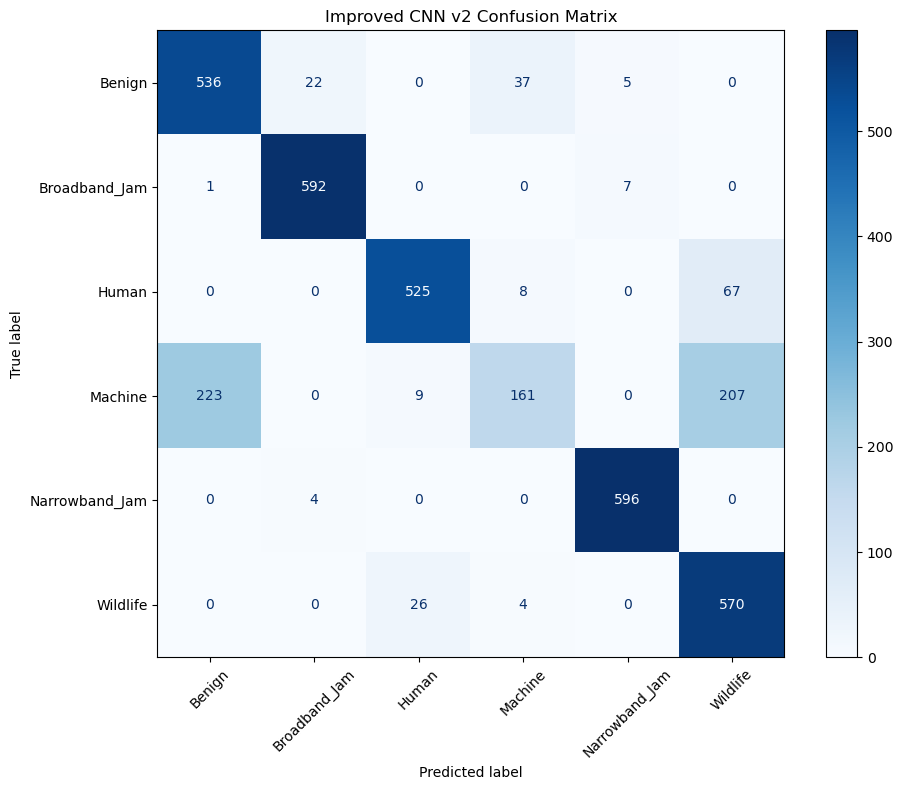

In [34]:
# ============================================
# Improved CNN v2 Classification Performance
# ============================================

from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
    precision_recall_fscore_support
)

# Generate improved model probabilities
improved_y_prob = improved_model.predict(
    test_ds,
    verbose=1
)

# Convert probabilities to class predictions
improved_y_pred = np.argmax(
    improved_y_prob,
    axis=1
)

# Classification report
print("Improved CNN v2 Classification Report")
print("-------------------------------------")

print(
    classification_report(
        y_true,
        improved_y_pred,
        target_names=class_names,
        digits=4
    )
)

# Calculate macro metrics
(
    improved_macro_precision,
    improved_macro_recall,
    improved_macro_f1,
    _
) = precision_recall_fscore_support(
    y_true,
    improved_y_pred,
    average="macro",
    zero_division=0
)

# Confusion matrix
improved_cm = confusion_matrix(
    y_true,
    improved_y_pred
)

disp = ConfusionMatrixDisplay(
    confusion_matrix=improved_cm,
    display_labels=class_names
)

fig, ax = plt.subplots(figsize=(10, 8))

disp.plot(
    ax=ax,
    cmap="Blues",
    values_format="d"
)

plt.title("Improved CNN v2 Confusion Matrix")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

## 25. Baseline vs Improved CNN Comparison

The improved CNN achieved higher overall test accuracy and lower test loss than the baseline CNN. Test accuracy increased from 81.22% to 82.78%, while test loss decreased from 0.4076 to 0.3454.

Macro F1-score also increased slightly from 0.8045 to 0.8065. However, the class-level results show an important tradeoff. Performance for the Wildlife class improved substantially, while recall and F1-score for the Machine class decreased.

The improved model therefore demonstrates stronger overall classification performance but still requires additional refinement to better distinguish Machine activity from Benign and Wildlife RF patterns.

In [35]:
# ============================================
# Baseline vs Improved CNN Comparison
# ============================================

comparison_results = {
    "Metric": [
        "Test Accuracy",
        "Test Loss",
        "Macro Precision",
        "Macro Recall",
        "Macro F1"
    ],
    "Baseline CNN v1": [
        baseline_results["test_accuracy"],
        baseline_results["test_loss"],
        baseline_results["macro_precision"],
        baseline_results["macro_recall"],
        baseline_results["macro_f1"]
    ],
    "Improved CNN v2": [
        improved_test_accuracy,
        improved_test_loss,
        improved_macro_precision,
        improved_macro_recall,
        improved_macro_f1
    ]
}

import pandas as pd

comparison_df = pd.DataFrame(comparison_results)

print("Baseline CNN v1 vs Improved CNN v2")
print("-----------------------------------")
print(comparison_df.to_string(index=False))

Baseline CNN v1 vs Improved CNN v2
-----------------------------------
         Metric  Baseline CNN v1  Improved CNN v2
  Test Accuracy         0.812222         0.827778
      Test Loss         0.407642         0.345406
Macro Precision         0.806918         0.837163
   Macro Recall         0.812222         0.827778
       Macro F1         0.804535         0.806542


## 26. Save Improved CNN v2

The improved CNN is saved as a separate model artifact so that it can be evaluated independently from the baseline CNN.

Model v2 achieved higher overall test accuracy and lower test loss than Model v1. The saved artifact preserves the trained model for additional evaluation, comparison, and deployment work by the project team.

In [36]:
# ============================================
# Save Improved CNN v2
# ============================================

improved_model_filename = "improved_cnn_rf_intrusion_v2.keras"

improved_model.save(
    improved_model_filename
)

print("Improved CNN v2 saved successfully.")
print(f"Model file: {improved_model_filename}")
print(f"Test Accuracy: {improved_test_accuracy:.4f}")
print(f"Test Loss:     {improved_test_loss:.4f}")
print(f"Macro F1:      {improved_macro_f1:.4f}")

Improved CNN v2 saved successfully.
Model file: improved_cnn_rf_intrusion_v2.keras
Test Accuracy: 0.8278
Test Loss:     0.3454
Macro F1:      0.8065


## 27. Improved CNN v2 Metadata

Metadata is created for the improved CNN to document the model version, architecture, training configuration, class labels, and evaluation results.

Saving this information alongside the trained model improves reproducibility and gives the project team a clear record of the exact model being evaluated and prepared for deployment.

In [40]:
# ============================================
# Improved CNN v2 Metadata
# ============================================

import json
from datetime import datetime, timezone

improved_model_metadata = {
    "model_name": "Improved CNN RF Intrusion Detection",
    "model_version": "v2",
    "model_type": "Convolutional Neural Network",

    "input_shape": [
        IMG_HEIGHT,
        IMG_WIDTH,
        3
    ],

    "num_classes": num_classes,
    "class_names": list(class_names),

    "architecture": {
        "convolution_blocks": 4,
        "filters": [32, 64, 128, 256],
        "batch_normalization": True,
        "dense_units": 128,
        "dropout_rate": 0.40
    },

    "training": {
        "optimizer": "Adam",
        "initial_learning_rate": 0.0005,
        "loss": "categorical_crossentropy",
        "max_epochs": 20,
        "early_stopping": True,
        "reduce_lr_on_plateau": True
    },

    "evaluation": {
        "test_loss": float(improved_test_loss),
        "test_accuracy": float(improved_test_accuracy),
        "macro_precision": float(improved_macro_precision),
        "macro_recall": float(improved_macro_recall),
        "macro_f1": float(improved_macro_f1)
    },

    "created_utc": datetime.now(
        timezone.utc
    ).isoformat()
}

improved_metadata_filename = (
    "improved_cnn_rf_intrusion_v2_metadata.json"
)

with open(
    improved_metadata_filename,
    "w"
) as f:
    json.dump(
        improved_model_metadata,
        f,
        indent=4
    )

print("Improved CNN v2 metadata saved successfully.")
print(f"Metadata file: {improved_metadata_filename}")

print("\nModel Metadata")
print("--------------")
print(
    json.dumps(
        improved_model_metadata,
        indent=4
    )
)

Improved CNN v2 metadata saved successfully.
Metadata file: improved_cnn_rf_intrusion_v2_metadata.json

Model Metadata
--------------
{
    "model_name": "Improved CNN RF Intrusion Detection",
    "model_version": "v2",
    "model_type": "Convolutional Neural Network",
    "input_shape": [
        128,
        128,
        3
    ],
    "num_classes": 6,
    "class_names": [
        "Benign",
        "Broadband_Jam",
        "Human",
        "Machine",
        "Narrowband_Jam",
        "Wildlife"
    ],
    "architecture": {
        "convolution_blocks": 4,
        "filters": [
            32,
            64,
            128,
            256
        ],
        "batch_normalization": true,
        "dense_units": 128,
        "dropout_rate": 0.4
    },
    "training": {
        "optimizer": "Adam",
        "initial_learning_rate": 0.0005,
        "loss": "categorical_crossentropy",
        "max_epochs": 20,
        "early_stopping": true,
        "reduce_lr_on_plateau": true
    },
    "e

In [42]:
# ============================================
# S3 Client Setup
# ============================================

import boto3

region = "us-east-1"

bucket = (
    "aai540-group6-rf-intrusion-2026-"
    "003274228913-us-east-1-an"
)

s3 = boto3.client(
    "s3",
    region_name=region
)

print("S3 client initialized.")
print(f"Bucket: {bucket}")
print(f"Region: {region}")

S3 client initialized.
Bucket: aai540-group6-rf-intrusion-2026-003274228913-us-east-1-an
Region: us-east-1


## 28. Upload Improved CNN v2 to S3

The improved CNN model and its metadata are uploaded to Amazon S3 using a versioned model path.

Storing both artifacts in S3 ensures the trained model is preserved independently of the current SageMaker session and provides a shared location for team evaluation, deployment, and future model management activities.

In [43]:
# ============================================
# Upload Improved CNN v2 to S3
# ============================================

improved_model_version = "v2"

improved_model_key = (
    f"models/improved/{improved_model_version}/"
    f"{improved_model_filename}"
)

improved_metadata_key = (
    f"models/improved/{improved_model_version}/"
    f"{improved_metadata_filename}"
)

# Upload improved model
s3.upload_file(
    improved_model_filename,
    bucket,
    improved_model_key
)

# Upload metadata
s3.upload_file(
    improved_metadata_filename,
    bucket,
    improved_metadata_key
)

improved_model_s3_uri = (
    f"s3://{bucket}/{improved_model_key}"
)

improved_metadata_s3_uri = (
    f"s3://{bucket}/{improved_metadata_key}"
)

print("Improved CNN v2 uploaded successfully.")
print()
print("Model:")
print(improved_model_s3_uri)
print()
print("Metadata:")
print(improved_metadata_s3_uri)

Improved CNN v2 uploaded successfully.

Model:
s3://aai540-group6-rf-intrusion-2026-003274228913-us-east-1-an/models/improved/v2/improved_cnn_rf_intrusion_v2.keras

Metadata:
s3://aai540-group6-rf-intrusion-2026-003274228913-us-east-1-an/models/improved/v2/improved_cnn_rf_intrusion_v2_metadata.json


## 29. Verify Improved CNN v2 Artifacts in S3

The uploaded improved CNN artifacts are verified in Amazon S3 to confirm that both the trained model and metadata file were stored successfully.

This verification step helps ensure the model is available for team evaluation and later deployment activities.

In [44]:
# ============================================
# Verify Improved CNN v2 Artifacts in S3
# ============================================

model_head = s3.head_object(
    Bucket=bucket,
    Key=improved_model_key
)

metadata_head = s3.head_object(
    Bucket=bucket,
    Key=improved_metadata_key
)

model_size_mb = model_head["ContentLength"] / (1024 * 1024)
metadata_size_kb = metadata_head["ContentLength"] / 1024

print("Improved CNN v2 S3 Verification")
print("--------------------------------")
print(f"Model found:    YES")
print(f"Model size:     {model_size_mb:.2f} MB")
print()
print(f"Metadata found: YES")
print(f"Metadata size:  {metadata_size_kb:.2f} KB")

Improved CNN v2 S3 Verification
--------------------------------
Model found:    YES
Model size:     4.92 MB

Metadata found: YES
Metadata size:  1.13 KB


## 30. Improved CNN v2 Team Handoff

The improved CNN v2 model is ready for independent team evaluation.

Model v2 improved overall test accuracy from 81.22% to 82.78% and reduced test loss from 0.4076 to 0.3454 compared with the baseline CNN. Macro F1-score increased slightly from 0.8045 to 0.8065.

Class-level evaluation showed that overall performance improved, although the Machine class remains an area for future refinement. The trained model and associated metadata have been stored in the shared Amazon S3 bucket so they can be accessed for additional evaluation and deployment activities.

In [45]:
# ============================================
# Improved CNN v2 Team Handoff
# ============================================

print("Improved CNN v2 - Team Handoff")
print("--------------------------------")
print(f"Model Version:       v2")
print(f"Test Accuracy:       {improved_test_accuracy:.4f}")
print(f"Test Loss:           {improved_test_loss:.4f}")
print(f"Macro F1:            {improved_macro_f1:.4f}")

print("\nBaseline Reference")
print("------------------")
print(f"Baseline Accuracy:   {baseline_results['test_accuracy']:.4f}")
print(f"Baseline Macro F1:   {baseline_results['macro_f1']:.4f}")

print("\nS3 Model Artifact")
print("-----------------")
print(improved_model_s3_uri)

print("\nS3 Metadata Artifact")
print("--------------------")
print(improved_metadata_s3_uri)

Improved CNN v2 - Team Handoff
--------------------------------
Model Version:       v2
Test Accuracy:       0.8278
Test Loss:           0.3454
Macro F1:            0.8065

Baseline Reference
------------------
Baseline Accuracy:   0.8122
Baseline Macro F1:   0.8045

S3 Model Artifact
-----------------
s3://aai540-group6-rf-intrusion-2026-003274228913-us-east-1-an/models/improved/v2/improved_cnn_rf_intrusion_v2.keras

S3 Metadata Artifact
--------------------
s3://aai540-group6-rf-intrusion-2026-003274228913-us-east-1-an/models/improved/v2/improved_cnn_rf_intrusion_v2_metadata.json
